# Fire Spreading Advanced


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)
from src.data_preprocessing import sentinel_client
from src.fire_spreading_model import FireSpreadingAdvanced


## Sentinel Data:

In [7]:
# Setup Authentication
client_id = 'sh-83b3baad-681c-49ff-967c-a1fe3eed19a4'
client_secret = 'L9cE8ASdvwyY64jWo8nUJQRIZ37A0XpS'
sc = sentinel_client(client_id=client_id, client_secret=client_secret)

## Dixie Fire Analysis and Simulation
This notebook handles the data retrieval, target mask creation, and simulation of the Dixie Fire (2021) using Sentinel-2 satellite data.
### Visualizing Before and After (False Colour)
We define the bounding box for the Dixie Fire start area and retrieve imagery to visualize the impact of the fire. Note that mode="false_colour" is used to better highlight burn scars and vegetation.

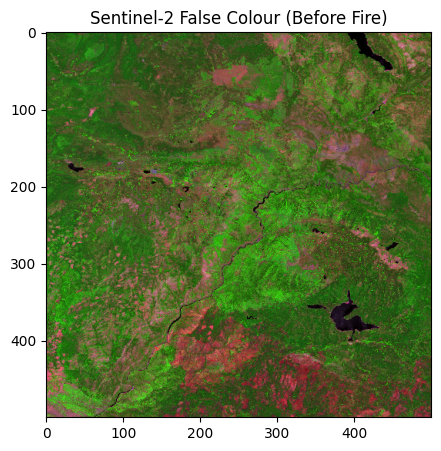

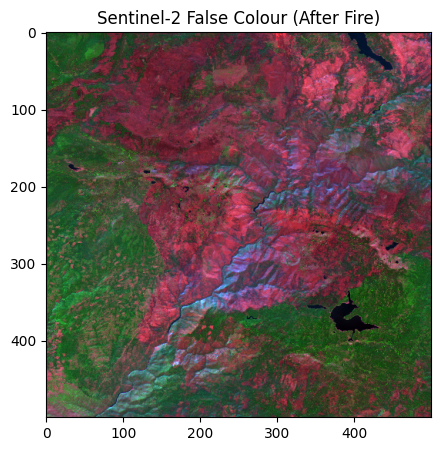

In [8]:
# Bounding box for the Dixie Fire start area
lon_min, lat_min, lon_max, lat_max = -121.50, 39.80, -121.10, 40.15
fire_start_date_1, fire_start_date_2 = "2021-07-13", "2021-07-14"
pixel_x, pixel_y = 500, 500 # pixel need to be adjusted for better resolution, but it will increase the runtime significantly
observation_end_date_1, observation_end_date_2 = "2021-08-15", "2021-08-30"

# Visualize imagery before the fire
photo_false_colour_before = sc.get_photo(lon_min, lat_min, lon_max, lat_max, fire_start_date_1, fire_start_date_2, pixel_x, pixel_y, mode="false_colour")
plt.figure(figsize=(5,5))
plt.imshow(photo_false_colour_before)
plt.title("Sentinel-2 False Colour (Before Fire)")
plt.show()

# Visualize imagery after the fire
photo_false_colour_after = sc.get_photo(lon_min, lat_min, lon_max, lat_max, observation_end_date_1, observation_end_date_2, pixel_x, pixel_y, mode="false_colour")
plt.figure(figsize=(5,5))
plt.imshow(photo_false_colour_after)
plt.title("Sentinel-2 False Colour (After Fire)")
plt.show()

### Data Retrieval and Target Mask Generation
We extract the Burn Ratio (from the enviromental index NBR) to create a ground-truth mask. The simulation time T is calculated by multipling the number of days in real time by 24. Therefore one simulation timestep would corespond to one hour.

In [ ]:
# Retrieve data
fuel_before, water_before, moisture_before, burnt_before = sc.get_data(lon_min, lat_min, lon_max, lat_max, fire_start_date_1, fire_start_date_2, pixel_x, pixel_y)
fuel_after_real_data, water_after_real_data, moisture_after_real_data, burnt_after_real_data = sc.get_data(lon_min, lat_min, lon_max, lat_max, observation_end_date_1, observation_end_date_2, pixel_x, pixel_y)

topo_mask = sc.get_topo(
    lon_min, lat_min, lon_max, lat_max,
    pixel_x, pixel_y
)

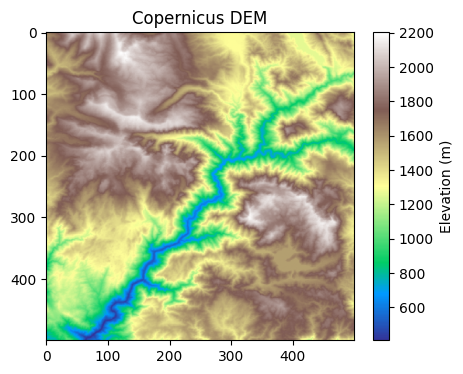

In [12]:
plt.figure(figsize=(5, 4))
plt.imshow(topo_mask, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Copernicus DEM")
plt.show()

In [ ]:
#dNBR = (NBR_before - NBR_after)
dnbr = (burnt_before - burnt_after_real_data)

# Create the Target Burn Mask based on NBR and water levels
target_mask = (dnbr > 0.1)

# Calculate simulation time in hours
T = sc.get_simulation_time(fire_start_date_1, observation_end_date_1) * 24
print(f"Simulation time (T): {T} time steps")

# Visualize the ground truth target mask
plt.figure(figsize=(5,5))
plt.imshow(target_mask, cmap='hot', interpolation='nearest')
plt.title("Target Burn Mask (Ground Truth)")
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(topo_mask, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Copernicus DEM")
plt.show()